# Library Imports and Utilities

In [315]:
import os
import enum
import math
import random
import sys
import warnings
from typing import List, Optional, Tuple, Dict, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import StepLR
from torch.distributions import Uniform
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
# Sklearn
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score, make_scorer, f1_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid

In [316]:
!pip install catboost

In [317]:
import catboost
from catboost import CatBoostClassifier

## Utilities

In [318]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
    return device

def fix_seed(seed):
    random.seed(seed)                           # Python's built-in random
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch
    torch.cuda.manual_seed(seed)                # CUDA (GPU)
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)

def get_workers():
    return os.cpu_count()

def check_gpu():
    device = get_device()
    print('Device:', device)
    print('Number of workers:', get_workers())
    return device

In [319]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

In [320]:
def collate_clt(batch):
    '''
    batch: a list of items. Each item can be:
        - (x_num_array, x_cat_array)                # for pretrain (without labels)
        - ((x_num_array, x_cat_array), label)       # for fine-tune/test (with labels, but they are not used)
    '''
    x_num_batch = []
    x_cat_batch = []
    for item in batch:
        # Check if the item is a 2‑element tuple, where the second element is not an array (likely a label)
        if isinstance(item, tuple) and len(item) == 2 and not isinstance(item[1], (np.ndarray, torch.Tensor)):
            # format ((x_num, x_cat), label)
            (x_num_arr, x_cat_arr), _ = item
        else:
            # format (x_num, x_cat) — without labels
            x_num_arr, x_cat_arr = item
        x_num_batch.append(torch.from_numpy(x_num_arr).float() if x_num_arr is not None else None)
        x_cat_batch.append(torch.from_numpy(x_cat_arr).long() if x_cat_arr is not None else None)

    x_num = torch.stack(x_num_batch) if x_num_batch[0] is not None else None
    x_cat = torch.stack(x_cat_batch) if x_cat_batch[0] is not None else None
    return x_num, x_cat

def collate_supervised(batch):
    '''
    batch: a list of items of the form ((x_num_array, x_cat_array), label)
    return: (x_num, x_cat, y)
    '''
    x_num_batch = []
    x_cat_batch = []
    y_batch = []
    for (x_num_arr, x_cat_arr), label in batch:
        x_num_batch.append(torch.from_numpy(x_num_arr).float() if x_num_arr is not None else None)
        x_cat_batch.append(torch.from_numpy(x_cat_arr).long() if x_cat_arr is not None else None)
        y_batch.append(label)

    x_num = torch.stack(x_num_batch) if x_num_batch[0] is not None else None
    x_cat = torch.stack(x_cat_batch) if x_cat_batch[0] is not None else None
    y = torch.tensor(y_batch, dtype=torch.float32)
    return x_num, x_cat, y

# ------------------------------------------------------------
# Function for one epoch of contrastive learning
# ------------------------------------------------------------
def train_epoch_clt(model, criterion, dataloader, optimizer, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0

    for x_num, x_cat in dataloader:
        if x_num is not None:
            x_num = x_num.to(device)
        if x_cat is not None:
            x_cat = x_cat.to(device)

        z1, z2 = model.forward_contrastive(x_num, x_cat)
        loss = criterion(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


# ------------------------------------------------------------
# Function for one epoch of supervised learning (fine‑tuning)
# ------------------------------------------------------------
def train_epoch_supervised(model, criterion, dataloader, optimizer, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0
    for x_num, x_cat, y in dataloader:
        if x_num is not None:
            x_num = x_num.to(device)
        if x_cat is not None:
            x_cat = x_cat.to(device)
        y = y.to(device).float()

        logits, _ = model(x_num, x_cat)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


# ------------------------------------------------------------
# Unified training function (pretraining or fine‑tuning)
# ------------------------------------------------------------
def train_model(
    model,
    train_loader,
    optimizer,
    scheduler,
    criterion,
    epochs,
    device,
    clip_grad=1.0,
    patience=10,
    is_pretrain=True,
    best_model_path='best_model.pt',
):
    best_loss = float('inf')
    patience_counter = 0
    loss_history = []

    for epoch in tqdm(range(1, epochs + 1)):
        if is_pretrain:
            avg_loss = train_epoch_clt(model, criterion, train_loader, optimizer, device, clip_grad)
        else:
            avg_loss = train_epoch_supervised(model, criterion, train_loader, optimizer, device, clip_grad)

        loss_history.append(avg_loss)
        scheduler.step()

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), best_model_path)
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f'epoch {epoch:3d}/{epochs} | loss: {avg_loss:.6f} | lr: {current_lr:.6f}')

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    model.load_state_dict(torch.load(best_model_path))
    print(f'Training finished. Best loss: {best_loss:.6f}')
    return loss_history

# **MODEL IMPLEMENTATION**

## **Tokenization**

In [321]:
# The code was taken from https://github.com/zha0wj/MODM/blob/main/rtdl.py

def _all_or_none(values):
    return all(x is None for x in values) or all(x is not None for x in values)

class _TokenInitialization(enum.Enum):
    UNIFORM = 'uniform'
    NORMAL = 'normal'

    @classmethod
    def from_str(cls, initialization: str) -> '_TokenInitialization':
        try:
            return cls(initialization)
        except ValueError:
            valid_values = [x.value for x in _TokenInitialization]
            raise ValueError(f'initialization must be one of {valid_values}')

    def apply(self, x: Tensor, d: int) -> None:
        d_sqrt_inv = 1 / math.sqrt(d)
        if self == _TokenInitialization.UNIFORM:
            # used in the paper "Revisiting Deep Learning Models for Tabular Data";
            # is equivalent to `nn.init.kaiming_uniform_(x, a=math.sqrt(5))` (which is
            # used by torch to initialize nn.Linear.weight, for example)
            nn.init.uniform_(x, a=-d_sqrt_inv, b=d_sqrt_inv)
        elif self == _TokenInitialization.NORMAL:
            nn.init.normal_(x, std=d_sqrt_inv)


class NumericalFeatureTokenizer(nn.Module):
    """Transforms continuous features to tokens (embeddings).

    See `FeatureTokenizer` for the illustration.

    For one feature, the transformation consists of two steps:

    * the feature is multiplied by a trainable vector
    * another trainable vector is added

    Note that each feature has its separate pair of trainable vectors, i.e. the vectors
    are not shared between features.

    Examples:
        .. testcode::

            x = torch.randn(4, 2)
            n_objects, n_features = x.shape
            d_token = 3
            tokenizer = NumericalFeatureTokenizer(n_features, d_token, True, 'uniform')
            tokens = tokenizer(x)
            assert tokens.shape == (n_objects, n_features, d_token)
    """

    def __init__(
        self,
        n_features: int,
        d_token: int,
        bias: bool,
        initialization: str,
    ) -> None:
        """
        Args:
            n_features: the number of continuous (scalar) features
            d_token: the size of one token
            bias: if `False`, then the transformation will include only multiplication.
                **Warning**: :code:`bias=False` leads to significantly worse results for
                Transformer-like (token-based) architectures.
            initialization: initialization policy for parameters. Must be one of
                :code:`['uniform', 'normal']`. Let :code:`s = d ** -0.5`. Then, the
                corresponding distributions are :code:`Uniform(-s, s)` and :code:`Normal(0, s)`.
                In [gorishniy2021revisiting], the 'uniform' initialization was used.

        References:
            * [gorishniy2021revisiting] Yury Gorishniy, Ivan Rubachev, Valentin Khrulkov, Artem Babenko, "Revisiting Deep Learning Models for Tabular Data", 2021
        """
        super().__init__()
        initialization_ = _TokenInitialization.from_str(initialization)
        self.weight = nn.Parameter(Tensor(n_features, d_token))
        self.bias = nn.Parameter(Tensor(n_features, d_token)) if bias else None
        for parameter in [self.weight, self.bias]:
            if parameter is not None:
                initialization_.apply(parameter, d_token)

    @property
    def n_tokens(self) -> int:
        """The number of tokens."""
        return len(self.weight)

    @property
    def d_token(self) -> int:
        """The size of one token."""
        return self.weight.shape[1]

    def forward(self, x: Tensor) -> Tensor:
        x = self.weight[None] * x[..., None]
        if self.bias is not None:
            x = x + self.bias[None]
        return x

In [322]:
class CategoricalFeatureTokenizer(nn.Module):
    """Transforms categorical features to tokens (embeddings).

    See `FeatureTokenizer` for the illustration.

    The module efficiently implements a collection of `torch.nn.Embedding` (with
    optional biases).

    Examples:
        .. testcode::

            # the input must contain integers. For example, if the first feature can
            # take 3 distinct values, then its cardinality is 3 and the first column
            # must contain values from the range `[0, 1, 2]`.
            cardinalities = [3, 10]
            x = torch.tensor([
                [0, 5],
                [1, 7],
                [0, 2],
                [2, 4]
            ])
            n_objects, n_features = x.shape
            d_token = 3
            tokenizer = CategoricalFeatureTokenizer(cardinalities, d_token, True, 'uniform')
            tokens = tokenizer(x)
            assert tokens.shape == (n_objects, n_features, d_token)
    """

    category_offsets: Tensor

    def __init__(
        self,
        cardinalities: List[int],
        d_token: int,
        bias: bool,
        initialization: str,
    ) -> None:
        """
        Args:
            cardinalities: the number of distinct values for each feature. For example,
                :code:`cardinalities=[3, 4]` describes two features: the first one can
                take values in the range :code:`[0, 1, 2]` and the second one can take
                values in the range :code:`[0, 1, 2, 3]`.
            d_token: the size of one token.
            bias: if `True`, for each feature, a trainable vector is added to the
                embedding regardless of feature value. The bias vectors are not shared
                between features.
            initialization: initialization policy for parameters. Must be one of
                :code:`['uniform', 'normal']`. Let :code:`s = d ** -0.5`. Then, the
                corresponding distributions are :code:`Uniform(-s, s)` and :code:`Normal(0, s)`. In
                the paper [gorishniy2021revisiting], the 'uniform' initialization was
                used.

        References:
            * [gorishniy2021revisiting] Yury Gorishniy, Ivan Rubachev, Valentin Khrulkov, Artem Babenko, "Revisiting Deep Learning Models for Tabular Data", 2021
        """
        super().__init__()
        assert cardinalities, 'cardinalities must be non-empty'
        assert d_token > 0, 'd_token must be positive'
        initialization_ = _TokenInitialization.from_str(initialization)
        category_offsets = torch.tensor([0] + cardinalities[:-1]).cumsum(0)
        self.register_buffer('category_offsets', category_offsets, persistent=False)
        self.embeddings = nn.Embedding(sum(cardinalities), d_token)
        self.bias = nn.Parameter(Tensor(len(cardinalities), d_token)) if bias else None

        for parameter in [self.embeddings.weight, self.bias]:
            if parameter is not None:
                initialization_.apply(parameter, d_token)

    @property
    def n_tokens(self) -> int:
        """The number of tokens."""
        return len(self.category_offsets)

    @property
    def d_token(self) -> int:
        """The size of one token."""
        return self.embeddings.embedding_dim

    def forward(self, x: Tensor) -> Tensor:
        x = self.embeddings(x + self.category_offsets[None])
        if self.bias is not None:
            x = x + self.bias[None]
        return x

## **loss function**

In [323]:
class NTXent(nn.Module):
    def __init__(self, temperature: float = 1.0) -> None:
        """NT-Xent loss for contrastive learning using cosine distance as similarity metric as used in [SimCLR](https://arxiv.org/abs/2002.05709).
        Implementation adapted from https://theaisummer.com/simclr/#simclr-loss-implementation

        Args:
            temperature (float, optional): scaling factor of the similarity metric. Defaults to 1.0.
        """
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i: Tensor, z_j: Tensor) -> Tensor:
        """Compute NT-Xent loss using only anchor and positive batches of samples. Negative samples are the 2*(N-1) samples in the batch

        Args:
            z_i (torch.tensor): anchor batch of samples
            z_j (torch.tensor): positive batch of samples

        Returns:
            float: loss
        """
        batch_size = z_i.size(0)

        # compute similarity between the sample's embedding and its corrupted view
        z = torch.cat([z_i, z_j], dim=0)
        similarity = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)

        sim_ij = torch.diag(similarity, batch_size)
        sim_ji = torch.diag(similarity, -batch_size)
        positives = torch.cat([sim_ij, sim_ji], dim=0)

        mask = (~torch.eye(batch_size * 2, batch_size * 2, dtype=torch.bool, device=z_i.device)).float()
        numerator = torch.exp(positives / self.temperature)
        denominator = mask * torch.exp(similarity / self.temperature)

        all_losses = -torch.log(numerator / torch.sum(denominator, dim=1))
        loss = torch.sum(all_losses) / (2 * batch_size)

        return loss

## **CLT_TAB**

In [324]:
class CLT_TAB_Dataset(Dataset):
    def __init__(
        self,
        data: pd.DataFrame,
        num_idx: List[int],
        cat_idx: List[int],
        cat_cardinalities: List[int],
        target: pd.Series = None,
    ):
        """
        Args:
            data: Feature DataFrame.
            num_idx: Indices of numerical columns.
            cat_idx: Indices of categorical columns.
            cat_cardinalities: Cardinalities per categorical column.
            target: Optional target variable.
        """
        if data.empty:
            raise ValueError('DataFrame "data" is empty.')
        if len(cat_idx) != len(cat_cardinalities):
            raise ValueError(
                f'Lengths cat_idx ({len(cat_idx)}) and cat_cardinalities ({len(cat_cardinalities)}) differ.'
            )

        self.num_data = data.iloc[:, num_idx].to_numpy(dtype=np.float32) if num_idx else None
        self.cat_data = data.iloc[:, cat_idx].to_numpy(dtype=np.int64) if cat_idx else None
        self.num_idx = num_idx
        self.cat_idx = cat_idx
        self.cat_cardinalities = cat_cardinalities

        self.has_targets = target is not None
        if self.has_targets:
            if len(target) != len(data):
                raise ValueError(f'Target length ({len(target)}) != data length ({len(data)})')
            self.targets = target.values.astype(np.int64).squeeze()

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        Returns:
            int: Total number of samples.
        """
        if self.num_data is not None:
            return len(self.num_data)
        elif self.cat_data is not None:
            return len(self.cat_data)
        else:
            return 0

    def __getitem__(self, idx):
        """
        Returns a dataset sample by index.
        Args:
            idx: Index of the sample.
        Returns:
            tuple: (x_num, x_cat) for unsupervised mode,
                   or ((x_num, x_cat), target) for supervised mode.
                   x_num — array of numerical features (or None),
                   x_cat — array of categorical features (or None).
        """
        x_num = self.num_data[idx] if self.num_data is not None else None
        x_cat = self.cat_data[idx] if self.cat_data is not None else None
        if self.has_targets:
            return (x_num, x_cat), self.targets[idx]
        return (x_num, x_cat)

In [325]:
# ============================================================
# TRANSFORMER ENCODER (Without POSITIONAL ENCODING)
# ============================================================
class TransformerEncoderLayerWithAttn(nn.Module):
    """
    Single Transformer Encoder layer with attention weights return.
    This layer does NOT use positional encoding
    because the order of features in tabular data is meaningless.
    """
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, src, src_mask=None, src_key_padding_mask=None, need_weights=True):
        """
        Forward pass with attention weights.
        Args:
            src: [batch_size, num_tokens, d_model]
            need_weights: If True, returns attention weights
        Returns:
            src: [batch_size, num_tokens, d_model] - encoded tokens
            attn_weights: [batch_size, num_heads, num_tokens, num_tokens] - attention maps
        """
        # ============================================================
        # FIX: Добавлен average_attn_weights=False
        # Было: self.self_attn(...) — по умолчанию average_attn_weights=True,
        #       возвращает [B, L, S] (усреднённый по головам)
        # Стало: average_attn_weights=False — всегда возвращает [B, heads, L, S]
        # Это необходимо для корректной работы _compute_feature_importance,
        # которая ожидает 4D тензор и усредняет по головам сама
        # ============================================================
        src2, attn_weights = self.self_attn(src, src, src, attn_mask=src_mask,
                                            key_padding_mask=src_key_padding_mask,
                                            need_weights=need_weights,
                                            average_attn_weights=False)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src, attn_weights


class TransformerEncoderWithAttn(nn.Module):
    """
    Transformer Encoder for tabular data WITHOUT positional encoding.
    Tokenizes numerical and categorical features, then processes them through
    stacked Transformer encoder layers. The first layer's attention is used
    for CATA (feature importance estimation).
    """
    def __init__(self, n_num_features, cat_cardinalities, d_token, num_layers=3,
                 num_heads=4, mul_f_head=4, dropout=0.1,
                 numerical_bias=True, categorical_bias=True,
                 initialization='uniform'):
        super().__init__()
        self.n_num_features = n_num_features
        self.n_cat_features = len(cat_cardinalities)

        if self.n_num_features > 0:
            self.num_tokenizer = NumericalFeatureTokenizer(
                n_features=self.n_num_features,
                d_token=d_token,
                bias=numerical_bias,
                initialization=initialization
            )
        else:
            self.num_tokenizer = None

        if self.n_cat_features > 0:
            self.cat_tokenizer = CategoricalFeatureTokenizer(
                cardinalities=cat_cardinalities,
                d_token=d_token,
                bias=categorical_bias,
                initialization=initialization
            )
        else:
            self.cat_tokenizer = None

        dim_feedforward = d_token * mul_f_head
        self.layers = nn.ModuleList([
            TransformerEncoderLayerWithAttn(d_token, num_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

        self.last_first_attn = None

    def forward(self, x_num, x_cat, return_attention=False, return_first_attn=False,
                # ============================================================
                # FIX: Добавлен параметр precomputed_tokens
                # Позволяет передать уже токенизированные данные (для positive ветки)
                # минуя повторную токенизацию. Это необходимо, потому что маскирование
                # теперь происходит на уровне эмбеддингов после токенизации
                # ============================================================
                precomputed_tokens=None):
        """
        Forward pass through the encoder.
        Args:
            x_num: [batch_size, n_num_features] - numerical features
            x_cat: [batch_size, n_cat_features] - categorical features (indices)
            return_attention: If True, returns attention weights from all layers
            return_first_attn: If True, returns attention from the first layer (used for CATA)
            precomputed_tokens: [batch_size, n_tokens, d_token] - already tokenized data
                When provided, skips tokenization (used for augmented positive branch)
        Returns:
            x: [batch_size, n_tokens, d_token] - encoded token sequence
            first_attn: (optional) attention from first layer
            attn_weights_list: (optional) attention from all layers
        """
        # ============================================================
        # Если переданы готовые токены — используем их
        # Иначе токенизируем сырые данные как обычно
        # ============================================================
        if precomputed_tokens is not None:
            x = precomputed_tokens
        else:
            tokens = []
            if x_num is not None and self.num_tokenizer is not None:
                tokens.append(self.num_tokenizer(x_num))
            if x_cat is not None and self.cat_tokenizer is not None:
                tokens.append(self.cat_tokenizer(x_cat))
            if not tokens:
                raise ValueError("No input features provided")
            x = torch.cat(tokens, dim=1)

        attn_weights_list = [] if return_attention else None
        first_attn = None

        for i, layer in enumerate(self.layers):
            need_weights = return_attention or (return_first_attn and i == 0)
            x, attn = layer(x, need_weights=need_weights)

            if need_weights:
                if return_first_attn and i == 0:
                    first_attn = attn
                    self.last_first_attn = attn
                if return_attention:
                    attn_weights_list.append(attn)

        if return_first_attn:
            return x, first_attn
        if return_attention:
            return x, attn_weights_list
        return x

In [326]:
# ============================================================
# MEAN POOLING
# ============================================================
class MeanPooling(nn.Module):
    """
    Mean Pooling — simple and effective token aggregation.
    Averages all feature tokens equally.

    Stochasticity in the pipeline comes from:
    - CATA: adaptive masking probabilities
    - Encoder dropout
    - DataLoader shuffle

    Args:
        d_token: Dimension of token embeddings (kept for API compatibility)
    """
    def __init__(self, d_token):
        super().__init__()
        self.d_token = d_token

    def forward(self, x, return_attention=False):
        """
        Args:
            x: Token sequence from encoder [batch_size, num_tokens, d_token]
            return_attention: If True, returns uniform attention weights (for API compatibility)
        Returns:
            pooled: Aggregated vector [batch_size, d_token]
            attn_weights: (optional) Uniform weights [batch_size, 1, 1, num_tokens]
        """
        pooled = x.mean(dim=1)  # [B, d_token]

        if return_attention:
            n = x.size(1)
            attn_weights = torch.ones(x.size(0), 1, 1, n, device=x.device) / n
            return pooled, attn_weights

        return pooled

In [327]:
# ============================================================
# CLT_TAB
# ============================================================
class CLT_TAB(nn.Module):
    """
    CLT-TAB: Contrastive Learning for Tabular Data.
    Key innovations:
    1. CATA (Continuous Adaptive Tabular Augmentation) — continuous probabilistic masking
       based on feature importance from the first encoder layer.
    2. Learnable mask embeddings in token space (applied after tokenization).
    3. Mean Pooling for token aggregation.
    Architecture pipeline:
        Raw data → CATA → Tokenizer → Mask Embedding → Transformer Encoder → Mean Pooling → Projection → InfoNCE Loss
    """
    def __init__(
        self,
        n_num_features: int,
        cat_cardinalities: List[int],
        d_token: int = 96,
        token_initialization: str = 'uniform',
        num_layers: int = 3,
        num_heads: int = 4,
        mul_f_head: int = 4,
        dropout: float = 0.1,
        mul_g_head: int = 4,
        projection_out: int = 128,
        numerical_bias: bool = True,
        categorical_bias: bool = True,
        corruption_rate: float = 0.6,
        CATA_alpha: float = 0.8,
    ):
        """
        Args:
            n_num_features: Number of numerical features.
            cat_cardinalities: List of cardinalities for categorical features (+1 for UNK).
            d_token: Token embedding dimension.
            token_initialization: 'uniform' or 'normal'.
            num_layers: Number of Transformer encoder layers.
            num_heads: Number of attention heads in encoder.
            mul_f_head: Multiplier for FFN hidden dimension (d_token * mul_f_head).
            dropout: Dropout rate in encoder.
            mul_g_head: Multiplier for projection head hidden dimension.
            projection_out: Output dimension of projection head.
            numerical_bias: If True, adds bias to numerical tokenizer.
            categorical_bias: If True, adds bias to categorical tokenizer.
            corruption_rate: Base masking rate for CATA.
            CATA_alpha: Controls influence of feature importance on masking probability.
                P_mask(i) = clamp(CR * (1 - alpha * importance(i)), 0.05, 0.95)
                Set CATA_alpha=0 for random masking (ablation mode).
        """
        super().__init__()
        self.n_num_features = n_num_features
        self.n_cat_features = len(cat_cardinalities)
        self.cat_cardinalities = cat_cardinalities
        self.corruption_rate = corruption_rate
        self.CATA_alpha = CATA_alpha

        # Validate cardinalities
        for card in cat_cardinalities:
            if card < 2:
                raise ValueError(f"Cardinality must be at least 2 (including UNK).")

        # ============================================================
        # LEARNABLE MASK EMBEDDINGS
        # Applied in token space after tokenization.
        # Separate embeddings for numerical and categorical features.
        # ============================================================
        self.d_token = d_token

        if self.n_num_features > 0:
            self.num_mask_embedding = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)
        else:
            self.num_mask_embedding = None

        if self.n_cat_features > 0:
            self.cat_mask_embedding = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)
        else:
            self.cat_mask_embedding = None

        # ============================================================
        # TRANSFORMER ENCODER
        # ============================================================
        self.encoder = TransformerEncoderWithAttn(
            n_num_features=n_num_features,
            cat_cardinalities=cat_cardinalities,
            d_token=d_token,
            num_layers=num_layers,
            num_heads=num_heads,
            mul_f_head=mul_f_head,
            dropout=dropout,
            numerical_bias=numerical_bias,
            categorical_bias=categorical_bias,
            initialization=token_initialization,
        )

        # ============================================================
        # MEAN POOLING
        # ============================================================
        self.pooling = MeanPooling(d_token)

        # ============================================================
        # PROJECTION HEAD
        # ============================================================
        hidden_dim = d_token * mul_g_head
        self.projection_head = nn.Sequential(
            nn.Linear(d_token, hidden_dim, bias=False),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, projection_out, bias=False),
            nn.LayerNorm(projection_out)
        )
        self.projection_out_dim = projection_out

    # ============================================================
    # CATA — FEATURE IMPORTANCE COMPUTATION
    # ============================================================
    def _compute_feature_importance(self, attn_weights, num_tokens):
        """
        Computes feature importance from the first encoder layer's attention.
        1. Average attention across heads: [B, heads, Q, K] -> [B, Q, K]
        2. Sum attention received by each token (over queries): [B, K]
        3. Normalize to mean=1 (not sum=1!) for meaningful alpha scaling.
        Args:
            attn_weights: [batch, heads, tokens, tokens] (4D, average_attn_weights=False)
            num_tokens: Total number of feature tokens
        Returns:
            importance: [batch, num_tokens] — mean ≈ 1.0
        """
        if attn_weights is None:
            return None

        # Average across heads
        attn = attn_weights.mean(dim=1)  # [B, Q, K]
        # Sum over queries
        importance = attn.sum(dim=1)  # [B, K]
        # Normalize to mean=1
        importance = importance / (importance.mean(dim=-1, keepdim=True) + 1e-8)

        if importance.dim() == 1:
            importance = importance.unsqueeze(0)

        if num_tokens > 0:
            return importance[:, :num_tokens]
        return None

    # ============================================================
    # CATA — ADAPTIVE AUGMENTATION
    # ============================================================
    def _apply_augmentation(self, x_num, x_cat, importance=None):
        """
        Computes per-feature masking probabilities and generates masks.
        Masking is applied at embedding level in forward_contrastive.

        CATA mode (CATA_alpha > 0):
            P_mask(i) = clamp(CR * (1 - alpha * importance(i)), 0.05, 0.95)
        Random mode (CATA_alpha = 0):
            P_mask(i) = CR (uniform)

        Args:
            x_num: [batch, n_num_features]
            x_cat: [batch, n_cat_features]
            importance: [batch, n_tokens] from CATA, ignored if CATA_alpha=0
        Returns:
            x_num, x_cat: unchanged input data
            mask_num: [batch, n_num_features] boolean mask
            mask_cat: [batch, n_cat_features] boolean mask
        """
        if x_num is not None:
            batch_size = x_num.shape[0]
            device = x_num.device
        elif x_cat is not None:
            batch_size = x_cat.shape[0]
            device = x_cat.device
        else:
            return None, None, None, None

        mask_num = None
        if x_num is not None and self.n_num_features > 0:
            if self.CATA_alpha and importance is not None:
                # Adaptive masking based on feature importance
                prob_num = self.corruption_rate * (1 - self.CATA_alpha * importance[:, :self.n_num_features])
                prob_num = torch.clamp(prob_num, 0.05, 0.95)
            else:
                # Random masking (ablation mode)
                prob_num = torch.full((batch_size, self.n_num_features), self.corruption_rate, device=device)

            mask_num = torch.rand(batch_size, self.n_num_features, device=device) < prob_num

            # Ensure at least one feature is masked
            if x_cat is None or self.n_cat_features == 0:
                mask_num |= ~mask_num.any(dim=1, keepdim=True)

        mask_cat = None
        if x_cat is not None and self.n_cat_features > 0:
            if self.CATA_alpha and importance is not None:
                prob_cat = self.corruption_rate * (1 - self.CATA_alpha * importance[:, self.n_num_features:])
                prob_cat = torch.clamp(prob_cat, 0.05, 0.95)
            else:
                prob_cat = torch.full((batch_size, self.n_cat_features), self.corruption_rate, device=device)

            mask_cat = torch.rand(batch_size, self.n_cat_features, device=device) < prob_cat

            if x_num is None or self.n_num_features == 0:
                mask_cat |= ~mask_cat.any(dim=1, keepdim=True)

        return x_num, x_cat, mask_num, mask_cat

    # ============================================================
    # FORWARD PASS FOR CONTRASTIVE LEARNING
    # ============================================================
    def forward_contrastive(self, x_num=None, x_cat=None) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Contrastive forward pass.
        1. Encode anchor, compute CATA importance from first layer attention
        2. Generate per-feature masks using CATA
        3. Tokenize, replace masked tokens with learnable mask embeddings
        4. Encode augmented tokens
        5. Mean pool, project, normalize
        """
        if x_num is None and x_cat is None:
            raise ValueError("At least one of x_num or x_cat must be provided.")

        # Step 1: Encode anchor, compute importance if CATA enabled
        if self.CATA_alpha and self.training:
            anchor_out, first_attn = self.encoder(x_num, x_cat, return_first_attn=True)
            n_total_tokens = self.n_num_features + self.n_cat_features
            importance = self._compute_feature_importance(first_attn, n_total_tokens)
        else:
            anchor_out = self.encoder(x_num, x_cat, return_attention=False)
            importance = None

        # Step 2: Get per-feature masks
        x_num_aug, x_cat_aug, mask_num, mask_cat = self._apply_augmentation(x_num, x_cat, importance)

        # Step 3: Tokenize and apply mask embeddings in token space
        tokens_aug = []
        batch_size = x_num_aug.shape[0] if x_num_aug is not None else x_cat_aug.shape[0]

        if x_num_aug is not None and self.encoder.num_tokenizer is not None:
            num_tokens = self.encoder.num_tokenizer(x_num_aug)  # [B, N_num, d_token]
            if mask_num is not None:
                mask_expanded = mask_num.float().unsqueeze(-1)  # [B, N_num, 1]
                num_mask_emb = self.num_mask_embedding.expand(batch_size, self.n_num_features, -1)
                num_tokens = num_tokens * (1 - mask_expanded) + num_mask_emb * mask_expanded
            tokens_aug.append(num_tokens)

        if x_cat_aug is not None and self.encoder.cat_tokenizer is not None:
            cat_tokens = self.encoder.cat_tokenizer(x_cat_aug)  # [B, N_cat, d_token]
            if mask_cat is not None:
                mask_expanded = mask_cat.float().unsqueeze(-1)  # [B, N_cat, 1]
                cat_mask_emb = self.cat_mask_embedding.expand(batch_size, self.n_cat_features, -1)
                cat_tokens = cat_tokens * (1 - mask_expanded) + cat_mask_emb * mask_expanded
            tokens_aug.append(cat_tokens)

        x_aug = torch.cat(tokens_aug, dim=1)

        # Step 4: Encode augmented tokens (skip tokenization via precomputed_tokens)
        positive_out = self.encoder(None, None, return_attention=False, precomputed_tokens=x_aug)

        # Step 5: Mean pool, project, normalize
        anchor_proj = F.normalize(self.projection_head(self.pooling(anchor_out)), dim=-1)
        positive_proj = F.normalize(self.projection_head(self.pooling(positive_out)), dim=-1)

        return anchor_proj, positive_proj

    # ============================================================
    # EMBEDDING EXTRACTION (Inference)
    # ============================================================
    @torch.inference_mode()
    def get_embeddings(self, x_num=None, x_cat=None) -> torch.Tensor:
        """Extract pooled embeddings for downstream tasks."""
        if x_num is None and x_cat is None:
            raise ValueError("At least one of x_num or x_cat must be provided.")
        tokens = self.encoder(x_num, x_cat, return_attention=False)
        return self.pooling(tokens, return_attention=False)

    @torch.inference_mode()
    def get_embeddings_with_attention(self, x_num=None, x_cat=None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Extract embeddings with uniform attention weights (for API compatibility)."""
        if x_num is None and x_cat is None:
            raise ValueError("At least one of x_num or x_cat must be provided.")
        tokens = self.encoder(x_num, x_cat, return_attention=False)
        pooled, attn_weights = self.pooling(tokens, return_attention=True)
        return pooled, attn_weights

In [328]:
def dataset_embeddings_collate(model, loader, device):
    """
    Extracts embeddings for the entire dataset.
    Process:
        1. Iterates through all batches in the dataloader
        2. Passes each batch through the model to get embeddings (after pooling)
        3. Concatenates all embeddings into a single array
    Note: The model is set to evaluation mode (no dropout, no batch norm updates).
    Args:
        model: CLT-TAB model
        loader: DataLoader with (x_num, x_cat) batches
        device: Device to run inference on (cpu or cuda)
    Returns:
        embeddings: numpy array of shape [n_samples, d_token] — embeddings for all samples
    """
    model.eval()
    embeddings = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting embeddings'):
            x_num, x_cat = batch
            if x_num is not None:
                x_num = x_num.to(device)
            if x_cat is not None:
                x_cat = x_cat.to(device)
            emb = model.get_embeddings(x_num, x_cat)

            # If embeddings are 3D (batch, seq_len, d_token), flatten them
            if emb.dim() == 3:
                emb = emb.flatten(start_dim=1)
            embeddings.append(emb.cpu())
    embeddings = torch.cat(embeddings, dim=0).numpy()
    print(f'Extracted embeddings shape: {embeddings.shape}')
    return embeddings

def extract_embeddings_and_attention(model, dataloader, device):
    """
    Extracts embeddings and attention weights for interpretability.
    Returns both:
        1. Pooled embeddings (after SQP) — used for downstream tasks
        2. SQP attention weights — show which features contributed most to aggregation
    The attention weights can be used for:
        - Global feature importance (averaging across samples)
        - Local interpretation (for individual samples)
        - Visualization as heatmaps
    Args:
        model: CLT-TAB model
        dataloader: DataLoader with (x_num, x_cat) batches
        device: Device to run inference on (cpu or cuda)
    Returns:
        embeddings: numpy array [n_samples, d_token] — pooled embeddings
        attention_weights: numpy array [n_samples, num_heads, 1, num_tokens] or None
            SQP attention weights showing feature importance per sample.
            Returns None if the model doesn't provide attention weights.
    """
    model.eval()
    all_embeddings = []
    all_attention_weights = []

    for x_num, x_cat in dataloader:
        if x_num is not None:
            x_num = x_num.to(device)
        if x_cat is not None:
            x_cat = x_cat.to(device)

        embeddings, attn_weights = model.get_embeddings_with_attention(x_num, x_cat)

        all_embeddings.append(embeddings.cpu())
        if attn_weights is not None:
            all_attention_weights.append(attn_weights.cpu())

    embeddings = torch.cat(all_embeddings, dim=0).numpy()

    if all_attention_weights:
        attention_weights = torch.cat(all_attention_weights, dim=0).numpy()
        return embeddings, attention_weights
    else:
        return embeddings, None

# Loading the dataset

In [329]:
import kagglehub
# Скачиваем датасет (файл окажется в локальном кэше)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
# Находим CSV-файл в скачанной папке и загружаем в df_raw
csv_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        break

if csv_path:
    df_raw = pd.read_csv(csv_path)
    print(f"✅ Данные загружены. Размер: {df_raw.shape}")
else:
    print("CSV файл не найден")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
✅ Данные загружены. Размер: (284807, 31)


In [330]:
df_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [331]:
X = preprocess_dataset(df_raw.drop(columns=['Class']))
y = (df_raw['Class']).astype(int).loc[X.index].squeeze()
y = replace_target(y)             # Меняем таргет при необходимости

No constant features were found
Size after preprocessing: (283726, 30)


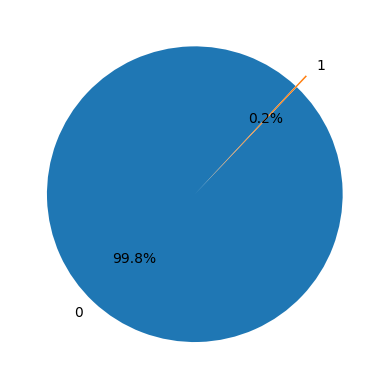

In [332]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [333]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 283253
Класс 1 : 473


In [334]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Наименование', 'Значения', 'Кол-во значений', 'Тип']).sort_values(by=['Кол-во значений', 'Наименование'])
unique_counts

,Наименование,Значения,Кол-во значений,Тип
29,Amount,"[149.62, 2.69, 378.66, 123.5, 69.99, 3.67, 4.9...",32767,float64
0,Time,"[0.0, 1.0, 2.0, 4.0, 7.0, 9.0, 10.0, 11.0, 12....",124592,float64
1,V1,"[-1.3598071336738, 1.19185711131486, -1.358354...",275663,float64
10,V10,"[0.0907941719789316, -0.166974414004614, 0.207...",275663,float64
11,V11,"[-0.551599533260813, 1.61272666105479, 0.62450...",275663,float64
12,V12,"[-0.617800855762348, 1.06523531137287, 0.06608...",275663,float64
13,V13,"[-0.991389847235408, 0.48909501589608, 0.71729...",275663,float64
14,V14,"[-0.311169353699879, -0.143772296441519, -0.16...",275663,float64
15,V15,"[1.46817697209427, 0.635558093258208, 2.345864...",275663,float64
16,V16,"[-0.470400525259478, 0.463917041022171, -2.890...",275663,float64


In [335]:
num_cols = X.columns.tolist()
cat_cols = []

# Data splitting and normalization

In [336]:
seed = 42
fix_seed(seed)

In [337]:
# ============================================================
# PART 1: DATA PREPARATION (for pretraining)
# ============================================================

# Parameters
desired_anomalies_test = 100          # Number of anomalies in test set
MAX_ANOMALIES_FT = 100                # Maximum number of anomalies in fine-tune pool
pretrain_size = 170000                # Pretraining dataset size (can be modified)

# Compute anomaly ratio in the original data
total_anomalies = y.sum()
natural_anomaly_ratio = total_anomalies / len(X)

# Calculate dataset sizes based on desired number of anomalies
test_size = int(desired_anomalies_test / natural_anomaly_ratio)
max_finetune_size = int(MAX_ANOMALIES_FT / natural_anomaly_ratio)

print("="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Original data: {len(X)} samples")
print(f"  Anomalies: {total_anomalies} ({natural_anomaly_ratio:.4f})")
print(f"  Normal: {len(X) - total_anomalies}")
print(f"\nTest size: {test_size} (target: {desired_anomalies_test} anomalies)")
print(f"Fine-tune pool size: {max_finetune_size} (max {MAX_ANOMALIES_FT} anomalies)")
print(f"Requested pretrain size: {pretrain_size}")

# --- Step 1: Split into test and MAXIMUM fine-tune pool ---
X_rest, X_test_raw, y_rest, y_test_raw = train_test_split(
    X, y, test_size=test_size, stratify=y, random_state=seed
)
X_pretrain_pool_raw, X_ft_pool_raw, y_pretrain_pool_raw, y_ft_pool_raw = train_test_split(
    X_rest, y_rest, test_size=max_finetune_size, stratify=y_rest, random_state=seed
)

# ========== PRETRAIN SIZE CHECK ==========
max_available_pretrain = len(X_pretrain_pool_raw)

if pretrain_size > max_available_pretrain:
    print(f"⚠️ WARNING: pretrain_size={pretrain_size} > available={max_available_pretrain}")
    print(f"   Setting pretrain_size to {max_available_pretrain}")
    pretrain_size = max_available_pretrain

# --- Save raw data for CatBoost (no transformations) ---
X_ft_raw_pool = X_ft_pool_raw.copy()
X_test_raw = X_test_raw.copy()
y_ft_raw_pool = y_ft_pool_raw.copy()
y_test_raw = y_test_raw.copy()

# --- Step 2: Learn transformations ONLY on pretrain_pool_raw ---
cat_mappings = {}
if cat_cols:
    for col in cat_cols:
        uniq = X_pretrain_pool_raw[col].astype(str).unique()
        cat_mappings[col] = {v: i for i, v in enumerate(uniq)}
    cat_cardinalities = [len(m) + 1 for m in cat_mappings.values()]
else:
    cat_cardinalities = []

if num_cols:
    scaler = StandardScaler()
    scaler.fit(X_pretrain_pool_raw[num_cols])
else:
    scaler = None

# --- Step 3: Apply transformations ---
def transform(data):
    """Apply learned transformations to data.
    Args:
        data: Raw DataFrame with original features
    Returns:
        Transformed DataFrame with standardized numeric features and encoded categorical features
    """
    data = data.copy()
    if num_cols and scaler is not None:
        data[num_cols] = scaler.transform(data[num_cols])
    for col in cat_cols:
        data[col] = data[col].astype(str).map(cat_mappings[col]).fillna(len(cat_mappings[col])).astype('int64')
    return data

X_pretrain_pool = transform(X_pretrain_pool_raw)
X_ft_pool = transform(X_ft_pool_raw)
X_test = transform(X_test_raw)

# ============================================================
# CREATE FIXED ORDER FOR INCREMENTAL SAMPLING
# ============================================================

# Create a fixed permutation of indices for the pretrain pool.
# This ensures that for different pretrain sizes, the samples are nested:
# e.g., pretrain_size=10k subset of pretrain_size=20k subset of pretrain_size=30k
rng = np.random.RandomState(seed)
all_pretrain_indices = np.arange(len(y_pretrain_pool_raw))
FIXED_PRETRAIN_ORDER = rng.permutation(all_pretrain_indices)

print(f"✅ Fixed order created for pretrain")
print(f"   Total indices: {len(FIXED_PRETRAIN_ORDER)}")
print(f"   First 10: {FIXED_PRETRAIN_ORDER[:10]}")

def get_pretrain_indices(target_size):
    """Returns the first target_size indices from the fixed order.
    Args:
        target_size: Number of samples to select
    Returns:
        Array of indices for the pretrain set
    """
    if target_size > len(FIXED_PRETRAIN_ORDER):
        target_size = len(FIXED_PRETRAIN_ORDER)
    return FIXED_PRETRAIN_ORDER[:target_size]

# ============================================================
# PRETRAIN SAMPLING
# ============================================================

# Select the first pretrain_size indices from the fixed order
pretrain_indices = get_pretrain_indices(pretrain_size)

X_pretrain = X_pretrain_pool.iloc[pretrain_indices]
y_pretrain = y_pretrain_pool_raw.iloc[pretrain_indices]

# --- Final variables for pretraining ---
pretrain_data = X_pretrain
pretrain_target = y_pretrain

# --- Save pools for subsequent fine-tuning ---
ft_pool_data = X_ft_pool
ft_pool_target = y_ft_pool_raw
test_data = X_test
test_target = y_test_raw

# Detailed output
print("\n" + "-"*40)
print("RESULT:")
print("-"*40)
print(f"Pretrain data: {len(pretrain_data)} samples")
print(f"Anomalies: {pretrain_target.sum()} ({pretrain_target.mean():.4f})")
print(f"Normal: {len(pretrain_target) - pretrain_target.sum()}")
print(f"\nFine-tune pool: {len(ft_pool_data)} samples")
print(f"Anomalies: {ft_pool_target.sum()} ({ft_pool_target.mean():.4f})")
print(f"Normal: {len(ft_pool_target) - ft_pool_target.sum()}")
print(f"\nTest data: {len(test_data)} samples")
print(f"Anomalies: {test_target.sum()} ({test_target.mean():.4f})")
print(f"Normal: {len(test_target) - test_target.sum()}")
print("="*60)

DATA PREPARATION
Original data: 283726 samples
  Anomalies: 473 (0.0017)
  Normal: 283253

Test size: 59984 (target: 100 anomalies)
Fine-tune pool size: 59984 (max 100 anomalies)
Requested pretrain size: 170000
⚠️ WARNING: pretrain_size=170000 > available=163758
   Setting pretrain_size to 163758
✅ Fixed order created for pretrain
   Total indices: 163758
   First 10: [  3899 143632 157224  56210 147869  43242 146456  51205  70024  70232]

----------------------------------------
RESULT:
----------------------------------------
Pretrain data: 163758 samples
Anomalies: 273 (0.0017)
Normal: 163485

Fine-tune pool: 59984 samples
Anomalies: 100 (0.0017)
Normal: 59884

Test data: 59984 samples
Anomalies: 100 (0.0017)
Normal: 59884


In [338]:
# ============================================================
# FEATURE INDEXES
# ============================================================
# Get column indices for numerical and categorical features from the pretrain data
num_idx = [pretrain_data.columns.get_loc(col) for col in num_cols]
cat_idx = [pretrain_data.columns.get_loc(col) for col in cat_cols]

# ============================================================
# LENGTH VALIDATION BEFORE DATASET CREATION
# ============================================================
print(f"\nLength validation before dataset creation:")
print(f"  pretrain_data: {len(pretrain_data)}, pretrain_target: {len(pretrain_target)}")

# Align indices (in case pandas indices are out of sync)
pretrain_target.index = pretrain_data.index

# ============================================================
# CREATE DATASET FOR PRETRAINING
# ============================================================
pretrain_ds = CLT_TAB_Dataset(
    data=pretrain_data,
    target=pretrain_target,    # Real labels (the model ignores them during pretraining)
    num_idx=num_idx,
    cat_idx=cat_idx,
    cat_cardinalities=cat_cardinalities
)

print(f"\nDatasets successfully created:")
print(f"  pretrain_ds: {len(pretrain_ds)} samples (labels are NOT used by the model during pretraining)")


Length validation before dataset creation:
  pretrain_data: 163758, pretrain_target: 163758

Datasets successfully created:
  pretrain_ds: 163758 samples (labels are NOT used by the model during pretraining)


# **Pretraining CLT-TAB** (generate embeddings for unlabeled data)

In [378]:
print(f"\nPretrain: {len(pretrain_data)} samples")
print(f"  — anomalies: {pretrain_target.sum()} ({pretrain_target.mean()*100:.4f}%)")
print(f"\nStratification check (anomaly ratio):")
print(f"  Pretrain: {pretrain_target.mean()*100:.4f}%")


Pretrain: 163758 samples
  — anomalies: 273 (0.1667%)

Stratification check (anomaly ratio):
  Pretrain: 0.1667%


In [379]:
device = check_gpu()

Device: cuda
Number of workers: 2


In [380]:
model = CLT_TAB(
    # Input data parameters
    n_num_features=len(num_idx),
    cat_cardinalities=cat_cardinalities,

    # Augmentation parameters (CATA)
    corruption_rate=0.6,  # Base masking rate
    CATA_alpha=0.8,       # Controls influence of feature importance on masking probability.
                          # Formula: P_mask(i) = clamp(CR * (1 - alpha * importance(i)), 0.05, 0.95)
                          # importance is normalized to mean=1 across features:
                          #   importance ≈ 2.0 (2x more important than avg) → 0.6*(1-1.6) = -0.36 → clamp→ 0.05 (5%)
                          #   importance ≈ 1.5 (50% more important)        → 0.6*(1-1.2) = -0.12 → clamp→ 0.05 (5%)
                          #   importance ≈ 1.0 (average importance)        → 0.6*(1-0.8) = 0.12 → 12%
                          #   importance ≈ 0.5 (2x less important)         → 0.6*(1-0.4) = 0.36 → 36%
                          #   importance ≈ 0.2 (5x less important)         → 0.6*(1-0.16) = 0.50 → 50%
                          # Contrast: 5% (important) vs 36-50% (unimportant) = 7-10x difference
                          # Set CATA_alpha=0 for random masking (ablation mode).

    # Encoder parameters
    d_token=96,
    token_initialization='uniform',
    num_layers=3,
    num_heads=4,
    mul_f_head=4,
    dropout=0.1,

    # Projection parameters
    mul_g_head=2,
    projection_out=128
).to(device)

criterion = NTXent(temperature=0.13)  # Contrastive loss with fixed temperature
batch_size = 256
epochs = 50

In [381]:
fix_seed(seed)

In [382]:
train_loader = DataLoader(pretrain_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_clt, drop_last=True)
# Create optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# Cosine annealing scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-4)

In [383]:
# ============================================================
# VERIFICATION FUNCTION
# ============================================================
def verify_after_training(model, dataloader):
    """
    Post-training verification of CATA, mask embeddings, and embeddings quality.
    """
    model.eval()

    batch = next(iter(dataloader))
    x_num, x_cat = batch
    x_num = x_num.to(device)
    if x_cat is not None:
        x_cat = x_cat.to(device)

    print("=" * 60)
    print("🔍 POST-TRAINING VERIFICATION")
    print("=" * 60)

    # ============================================================
    # 1. CATA — Feature Importance
    # ============================================================
    print("\n📊 1. CATA — Feature Importance After Training")
    print("-" * 40)

    with torch.no_grad():
        anchor_out, first_attn = model.encoder(x_num, x_cat, return_first_attn=True)
        n_total = model.n_num_features + model.n_cat_features
        importance = model._compute_feature_importance(first_attn, n_total)

    importance_std = importance.std(dim=0).mean().item()
    importance_min = importance.min().item()
    importance_max = importance.max().item()
    importance_per_feature = importance.mean(dim=0)

    print(f"Importance statistics:")
    print(f"  Mean: {importance.mean().item():.4f} (expected: ~1.0)")
    print(f"  Std:  {importance_std:.4f} (before training: ~0.0003)")
    print(f"  Min:  {importance_min:.4f}")
    print(f"  Max:  {importance_max:.4f}")
    print(f"  Range: {importance_max - importance_min:.4f}")

    if importance_std > 0.1:
        print(f"✅ CATA is FULLY TRAINED — strong feature differentiation (std={importance_std:.3f})")
    elif importance_std > 0.05:
        print(f"⚠️  CATA has some differentiation — continue training (std={importance_std:.3f})")
    else:
        print(f"❌ CATA not learning — std={importance_std:.4f}")

    # Top and bottom features
    sorted_idx = importance_per_feature.argsort(descending=True)
    top5 = sorted_idx[:5]
    bottom5 = sorted_idx[-5:]

    print(f"\nTop 5 important features:")
    for i, idx in enumerate(top5):
        print(f"  {i+1}. Feature {idx.item():3d}: importance = {importance_per_feature[idx].item():.4f}")

    print(f"Bottom 5 features:")
    for i, idx in enumerate(bottom5):
        print(f"  {i+1}. Feature {idx.item():3d}: importance = {importance_per_feature[idx].item():.4f}")

    # Masking probabilities
    print(f"\nMasking probabilities (CR={model.corruption_rate}, alpha={model.CATA_alpha}):")
    for name, idx in [("Top feature", top5[0]), ("Median feature", sorted_idx[len(sorted_idx)//2]), ("Bottom feature", bottom5[0])]:
        imp = importance_per_feature[idx].item()
        prob = model.corruption_rate * (1 - model.CATA_alpha * imp)
        prob_clamped = max(0.05, min(0.95, prob))
        print(f"  {name} (feat {idx.item()}): importance={imp:.3f} → prob={prob:.3f} → clamped={prob_clamped:.3f}")

    # ============================================================
    # 2. NEUTRAL TOKEN — Mask Embeddings
    # ============================================================
    print("\n📊 2. NEUTRAL TOKEN — Learned Mask Embeddings")
    print("-" * 40)

    num_norm = None
    cat_norm = None

    if model.num_mask_embedding is not None:
        num_norm = model.num_mask_embedding.norm().item()
        print(f"Numerical mask embedding norm: {num_norm:.4f}")

    if model.cat_mask_embedding is not None:
        cat_norm = model.cat_mask_embedding.norm().item()
        print(f"Categorical mask embedding norm: {cat_norm:.4f}")

    if model.num_mask_embedding is not None and model.cat_mask_embedding is not None:
        diff = (model.num_mask_embedding - model.cat_mask_embedding).norm().item()
        print(f"Difference between num and cat mask embeddings: {diff:.4f}")

    if model.num_mask_embedding is not None and model.encoder.num_tokenizer is not None:
        with torch.no_grad():
            real_tokens = model.encoder.num_tokenizer(x_num)
            real_mean = real_tokens.mean(dim=(0, 1))
            mask_vec = model.num_mask_embedding.squeeze()
            cosine_sim = torch.cosine_similarity(real_mean.unsqueeze(0), mask_vec.unsqueeze(0)).item()
        print(f"Cosine similarity (num mask vs mean real token): {cosine_sim:.4f}")
        if abs(cosine_sim) < 0.5:
            print("✅ Mask embedding is DISTINCT from real tokens — model can identify masks")
        else:
            print("⚠️  Mask embedding is similar to real tokens — may reduce contrastive effect")

    # ============================================================
    # 3. EMBEDDING QUALITY
    # ============================================================
    print("\n📊 3. EMBEDDING QUALITY CHECK")
    print("-" * 40)

    with torch.no_grad():
        embeddings = model.get_embeddings(x_num, x_cat)

    emb_std = embeddings.std(dim=0).mean().item()
    emb_norm = embeddings.norm(dim=1).mean().item()

    print(f"Embedding shape: {embeddings.shape}")
    print(f"Embedding norm (mean): {emb_norm:.4f}")
    print(f"Embedding std (mean over dims): {emb_std:.4f}")

    if emb_std > 0.1:
        print("✅ Embeddings are not collapsed — good representation diversity")
    elif emb_std > 0.01:
        print("⚠️  Low diversity — possible partial collapse")
    else:
        print("❌ Embeddings collapsed — check training")

    print("\n" + "=" * 60)
    print("✅ POST-TRAINING VERIFICATION COMPLETE")
    print("=" * 60)

    return {
        'importance_std': importance_std,
        'importance_range': importance_max - importance_min,
        'embedding_std': emb_std,
        'num_mask_norm': num_norm,
        'cat_mask_norm': cat_norm,
    }


# ============================================================
# PRE-TRAINING BASELINE
# ============================================================
print("\n" + "="*60)
print("🔍 PRE-TRAINING BASELINE (Epoch 0)")
print("="*60)

model.eval()
batch = next(iter(train_loader))
x_num, x_cat = batch
x_num = x_num.to(device)
if x_cat is not None:
    x_cat = x_cat.to(device)

with torch.no_grad():
    anchor_out, first_attn = model.encoder(x_num, x_cat, return_first_attn=True)
    n_total = model.n_num_features + model.n_cat_features
    importance = model._compute_feature_importance(first_attn, n_total)

print(f"\n📊 CATA (untrained)")
print(f"  Std:  {importance.std(dim=0).mean().item():.4f}")
print(f"  Min:  {importance.min().item():.4f}")
print(f"  Max:  {importance.max().item():.4f}")

print(f"\n📊 NEUTRAL TOKEN (untrained)")
if model.num_mask_embedding is not None:
    print(f"  Num mask norm: {model.num_mask_embedding.norm().item():.4f}")
if model.cat_mask_embedding is not None:
    print(f"  Cat mask norm: {model.cat_mask_embedding.norm().item():.4f}")

baseline = {
    'cata_std': importance.std(dim=0).mean().item(),
}
print("\n✅ BASELINE SAVED")


🔍 PRE-TRAINING BASELINE (Epoch 0)

📊 CATA (untrained)
  Std:  0.0003
  Min:  0.9946
  Max:  1.0059

📊 NEUTRAL TOKEN (untrained)
  Num mask norm: 0.2001

✅ BASELINE SAVED


In [384]:
loss_history_pretrain = train_model(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    epochs=epochs,
    device=device,
    clip_grad=1.0,
    patience=100,   # without early stopping
    is_pretrain=True,
    best_model_path='best_pretrained_model.pt'
)

  0%|          | 0/50 [00:00<?, ?it/s]

epoch  10/50 | loss: 0.617666 | lr: 0.000914
epoch  20/50 | loss: 0.575235 | lr: 0.000689
epoch  30/50 | loss: 0.549578 | lr: 0.000411
epoch  40/50 | loss: 0.535811 | lr: 0.000186
epoch  50/50 | loss: 0.530770 | lr: 0.000100
Training finished. Best loss: 0.530502


In [385]:

# ============================================================
# ЗАПУСК ПОСЛЕ ОБУЧЕНИЯ
# ============================================================
results = verify_after_training(model, train_loader)

print("\n" + "="*60)
print("📈 COMPARISON: Baseline → After Training")
print("="*60)
print(f"CATA std:  {baseline['cata_std']:.4f} → {results['importance_std']:.4f}")
print(f"Importance range: → {results['importance_range']:.4f}")
print(f"Embedding std: {results['embedding_std']:.4f}")
if results['num_mask_norm'] is not None:
    print(f"Num mask norm: {results['num_mask_norm']:.4f}")
if results['cat_mask_norm'] is not None:
    print(f"Cat mask norm: {results['cat_mask_norm']:.4f}")

🔍 POST-TRAINING VERIFICATION

📊 1. CATA — Feature Importance After Training
----------------------------------------
Importance statistics:
  Mean: 1.0000 (expected: ~1.0)
  Std:  0.3363 (before training: ~0.0003)
  Min:  0.0593
  Max:  8.5611
  Range: 8.5018
✅ CATA is FULLY TRAINED — strong feature differentiation (std=0.336)

Top 5 important features:
  1. Feature  17: importance = 1.4179
  2. Feature   9: importance = 1.3642
  3. Feature  10: importance = 1.3551
  4. Feature  29: importance = 1.3515
  5. Feature  18: importance = 1.3241
Bottom 5 features:
  1. Feature  11: importance = 0.7317
  2. Feature  23: importance = 0.7221
  3. Feature  24: importance = 0.7105
  4. Feature  26: importance = 0.6552
  5. Feature   0: importance = 0.5320

Masking probabilities (CR=0.6, alpha=0.8):
  Top feature (feat 17): importance=1.418 → prob=-0.081 → clamped=0.050
  Median feature (feat 21): importance=0.917 → prob=0.160 → clamped=0.160
  Bottom feature (feat 11): importance=0.732 → prob=0.2

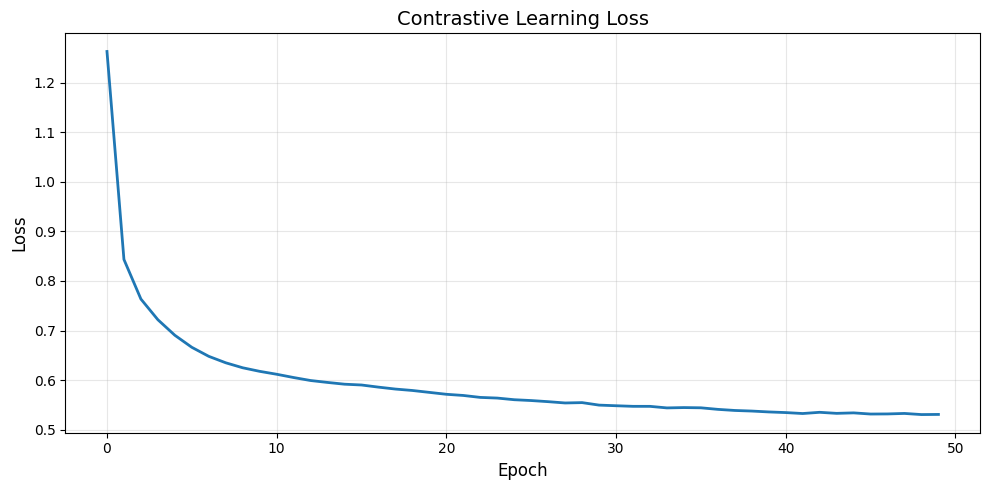

In [386]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history_pretrain, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Contrastive Learning Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

# Data preparation for fine‑tuning

In [387]:
# ============================================================
# PART 2: FINE-TUNE SAMPLING (after pretraining)
# ============================================================

desired_anomalies_ft = 100

print("\n" + "="*60)
print("PART 2: FINE-TUNE SAMPLING")
print("="*60)
print(f"Requested anomalies in fine-tune: {desired_anomalies_ft}")

max_anomalies_in_pool = ft_pool_target.sum()
print(f"Available anomalies in pool: {max_anomalies_in_pool}")

if desired_anomalies_ft > max_anomalies_in_pool:
    print(f"⚠️ WARNING: desired_anomalies_ft={desired_anomalies_ft} > available={max_anomalies_in_pool}")
    desired_anomalies_ft = max_anomalies_in_pool

# Calculate fine-tune size based on desired number of anomalies
finetune_size = int(desired_anomalies_ft / natural_anomaly_ratio)
print(f"Fine-tune size in samples: {finetune_size}")

max_available_ft = len(ft_pool_data)
if finetune_size > max_available_ft:
    print(f"⚠️ WARNING: finetune_size={finetune_size} > pool_size={max_available_ft}")
    finetune_size = max_available_ft
    anomaly_ratio_in_pool = ft_pool_target.sum() / len(ft_pool_data)
    desired_anomalies_ft = int(finetune_size * anomaly_ratio_in_pool)
    print(f"   Recalculated anomaly count: {desired_anomalies_ft}")

# ============================================================
# CREATE FIXED ORDER FOR FINE-TUNE SAMPLING
# ============================================================

# Create a fixed permutation for the fine-tune pool (separate from pretrain)
rng_ft = np.random.RandomState(seed + 1000)  # Different seed to avoid overlap
all_ft_indices = np.arange(len(ft_pool_target))
FIXED_FINETUNE_ORDER = rng_ft.permutation(all_ft_indices)

def get_finetune_indices(target_size):
    """Returns the first target_size indices from the fixed fine-tune order.
    Args:
        target_size: Number of samples to select
    Returns:
        Array of indices for the fine-tune set
    """
    if target_size > len(FIXED_FINETUNE_ORDER):
        target_size = len(FIXED_FINETUNE_ORDER)
    return FIXED_FINETUNE_ORDER[:target_size]

# Sample fine-tune data
ft_indices = get_finetune_indices(finetune_size)

finetune_data = ft_pool_data.iloc[ft_indices]
finetune_target = ft_pool_target.iloc[ft_indices]

# ============================================================
# CREATE VARIABLES FOR CATBOOST
# ============================================================

# Use raw data (before scaling/encoding) for CatBoost
X_ft_raw = X_ft_raw_pool.iloc[ft_indices].copy()
X_test_raw = X_test_raw.copy()
y_ft_raw = y_ft_raw_pool.iloc[ft_indices].copy()
y_test_raw = y_test_raw.copy()

# Convert categorical columns to strings (required by CatBoost)
for col in cat_cols:
    X_ft_raw[col] = X_ft_raw[col].astype(str)
    X_test_raw[col] = X_test_raw[col].astype(str)

actual_anomalies = finetune_target.sum()
expected_anomalies = desired_anomalies_ft

print(f"\nResult:")
print(f"  ✅ Fine-tune data: {len(finetune_data)} samples")
print(f"  Anomalies in fine-tune: {actual_anomalies} (expected: {expected_anomalies})")
print(f"  Anomaly ratio: {finetune_target.mean():.6f}")

original_ratio = ft_pool_target.mean()
deviation = abs(finetune_target.mean() - original_ratio)
if deviation < 0.0005:
    print(f"  ✅ Stratification OK (deviation: {deviation:.6f})")
else:
    print(f"  ⚠️ Stratification deviation: {deviation:.6f}")

print("="*60)


PART 2: FINE-TUNE SAMPLING
Requested anomalies in fine-tune: 100
Available anomalies in pool: 100
Fine-tune size in samples: 59984

Result:
  ✅ Fine-tune data: 59984 samples
  Anomalies in fine-tune: 100 (expected: 100)
  Anomaly ratio: 0.001667
  ✅ Stratification OK (deviation: 0.000000)


In [388]:
# ============================================================
# LENGTH VALIDATION BEFORE DATASET CREATION
# ============================================================
print(f"\nLength validation before dataset creation:")
print(f"  finetune_data: {len(finetune_data)}, finetune_target: {len(finetune_target)}")
print(f"  test_data: {len(test_data)}, test_target: {len(test_target)}")

# Align indices (in case pandas indices are out of sync)
finetune_target.index = finetune_data.index
test_target.index = test_data.index

# ============================================================
# CREATE DATASETS
# ============================================================
finetune_ds = CLT_TAB_Dataset(
    data=finetune_data,
    target=finetune_target,
    num_idx=num_idx,
    cat_idx=cat_idx,
    cat_cardinalities=cat_cardinalities
)
test_ds = CLT_TAB_Dataset(
    data=test_data,
    target=test_target,
    num_idx=num_idx,
    cat_idx=cat_idx,
    cat_cardinalities=cat_cardinalities
)
print(f"\nDatasets successfully created:")
print(f"  finetune_ds: {len(finetune_ds)} samples")
print(f"  test_ds: {len(test_ds)} samples")


Length validation before dataset creation:
  finetune_data: 59984, finetune_target: 59984
  test_data: 59984, test_target: 59984

Datasets successfully created:
  finetune_ds: 59984 samples
  test_ds: 59984 samples


In [389]:
# Get embeddings for finetuning and test
finetune_loader = DataLoader(finetune_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_clt)
finetune_embeddings = dataset_embeddings_collate(model, finetune_loader, device)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_clt)
test_embeddings = dataset_embeddings_collate(model, test_loader, device)
print(f'Finetune embeddings shape: {finetune_embeddings.shape}')
print(f'Test embeddings shape: {test_embeddings.shape}')

Extracting embeddings:   0%|          | 0/235 [00:00<?, ?it/s]

Extracted embeddings shape: (59984, 96)


Extracting embeddings:   0%|          | 0/235 [00:00<?, ?it/s]

Extracted embeddings shape: (59984, 96)
Finetune embeddings shape: (59984, 96)
Test embeddings shape: (59984, 96)


In [390]:
print(f"\n{'='*60}")
print("SPLIT STATISTICS (NO OVERLAP)")
print(f"{'='*60}")
print(f"\nPretrain: {len(pretrain_data)} instances")
print(f"  — anomalies: {pretrain_target.sum()} ({pretrain_target.mean()*100:.4f}%)")
print(f"\nFinetune: {len(finetune_data)} instances")
print(f"  — anomalies: {finetune_target.sum()} ({finetune_target.mean()*100:.4f}%)")
print(f"\nTest: {len(test_data)} instances")
print(f"  — anomalies: {test_target.sum()} ({test_target.mean()*100:.4f}%)")
print(f"\nPretrain/finetune ratio: {len(pretrain_data)/len(finetune_data):.2f}:1")

# Check for overlaps
pretrain_indices = set(pretrain_data.index)
ft_indices = set(finetune_data.index)
test_indices = set(test_data.index)
print(f"\nOverlap check:")
print(f"  pretrain ∩ finetune = {len(pretrain_indices & ft_indices)} instances")
print(f"  pretrain ∩ test = {len(pretrain_indices & test_indices)} instances")
print(f"  finetune ∩ test = {len(ft_indices & test_indices)} instances")

# Stratification check
print(f"\nStratification check (anomaly ratios):")
print(f"  Pretrain: {pretrain_target.mean()*100:.4f}%")
print(f"  Finetune: {finetune_target.mean()*100:.4f}%")
print(f"  Test: {test_target.mean()*100:.4f}%")
print(f"  Original: {natural_anomaly_ratio*100:.4f}%")


SPLIT STATISTICS (NO OVERLAP)

Pretrain: 163758 instances
  — anomalies: 273 (0.1667%)

Finetune: 59984 instances
  — anomalies: 100 (0.1667%)

Test: 59984 instances
  — anomalies: 100 (0.1667%)

Pretrain/finetune ratio: 2.73:1

Overlap check:
  pretrain ∩ finetune = 0 instances
  pretrain ∩ test = 0 instances
  finetune ∩ test = 0 instances

Stratification check (anomaly ratios):
  Pretrain: 0.1667%
  Finetune: 0.1667%
  Test: 0.1667%
  Original: 0.1667%


# 	Classification task

## Logistic Regression

In [391]:
# ============================================================
# LOGISTIC REGRESSION HYPERPARAMETERS
# ============================================================

# Grid search configuration for logistic regression fine-tuning
param_grid_lr = {
    'penalty': ['l2'],  # L2 regularization (standard for logistic regression)
    'C': np.logspace(-2, 0, 7).tolist(),  # Regularization strength: 0.01, 0.0215, 0.0464, 0.1, 0.215, 0.464, 1.0
    'solver': ['lbfgs']  # Solver for L2 penalty (efficient for small datasets)
}

# Evaluation metrics for grid search
scoring = {
    'f1': make_scorer(f1_score),  # F1 score for imbalanced classification
    'auprc': make_scorer(average_precision_score),  # Area Under Precision-Recall Curve (main metric)
    'recall': make_scorer(recall_score)  # Recall (sensitivity)
}

# Cross-validation strategy (stratified to preserve class distribution)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

In [392]:
fix_seed(seed)

In [393]:
print("="*50)
print("1. LOGISTIC REGRESSION ON ORIGINAL FEATURES")
print("="*50)

# Grid search with cross-validation on original (raw) features
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, class_weight='balanced', random_state=seed),
    param_grid=param_grid_lr,
    scoring=scoring,
    refit='auprc',  # Refit using AUPRC as the primary metric
    cv=skf,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(finetune_data, finetune_target)

print('Best parameters:', grid_search.best_params_)
best_idx = grid_search.best_index_
print(f"Best AUPRC (CV): {grid_search.best_score_:.4f}")
print(f"F1 (CV): {grid_search.cv_results_['mean_test_f1'][best_idx]:.4f}")
print(f"Recall (CV): {grid_search.cv_results_['mean_test_recall'][best_idx]:.4f}")

# Evaluate on test set
y_pred_orig = grid_search.predict(test_data)
probs_orig = grid_search.predict_proba(test_data)[:, 1]
print("\n--- Test set ---")
print(f"AUPRC: {average_precision_score(test_target, probs_orig):.4f}")
print(f"F1: {f1_score(test_target, y_pred_orig):.4f}")
print(f"Recall: {recall_score(test_target, y_pred_orig):.4f}")
print(classification_report(test_target, y_pred_orig))

1. LOGISTIC REGRESSION ON ORIGINAL FEATURES
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best AUPRC (CV): 0.0525
F1 (CV): 0.1088
Recall (CV): 0.9000

--- Test set ---
AUPRC: 0.6618
F1: 0.1099
Recall: 0.8800
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     59884
           1       0.06      0.88      0.11       100

    accuracy                           0.98     59984
   macro avg       0.53      0.93      0.55     59984
weighted avg       1.00      0.98      0.99     59984



In [394]:
fix_seed(seed)

In [395]:
print("\n" + "="*50)
print("2. LOGISTIC REGRESSION ON EMBEDDINGS")
print("="*50)

# Grid search with cross-validation on embeddings from CLT-TAB
grid_search2 = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, class_weight='balanced', random_state=seed),
    param_grid=param_grid_lr,
    scoring=scoring,
    refit='auprc',  # Refit using AUPRC as the primary metric
    cv=skf,
    verbose=1,
    n_jobs=-1
)
grid_search2.fit(finetune_embeddings, finetune_target)

print('Best parameters:', grid_search2.best_params_)
best_idx2 = grid_search2.best_index_
print(f"Best AUPRC (CV): {grid_search2.best_score_:.4f}")
print(f"F1 (CV): {grid_search2.cv_results_['mean_test_f1'][best_idx2]:.4f}")
print(f"Recall (CV): {grid_search2.cv_results_['mean_test_recall'][best_idx2]:.4f}")

# Evaluate on test set embeddings
y_pred_emb = grid_search2.predict(test_embeddings)
probs_emb = grid_search2.predict_proba(test_embeddings)[:, 1]
print("\n--- Test set ---")
print(f"AUPRC: {average_precision_score(test_target, probs_emb):.4f}")
print(f"F1: {f1_score(test_target, y_pred_emb):.4f}")
print(f"Recall: {recall_score(test_target, y_pred_emb):.4f}")
print(classification_report(test_target, y_pred_emb))


2. LOGISTIC REGRESSION ON EMBEDDINGS
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best AUPRC (CV): 0.0982
F1 (CV): 0.2069
Recall (CV): 0.8300

--- Test set ---
AUPRC: 0.6199
F1: 0.1707
Recall: 0.8400
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     59884
           1       0.10      0.84      0.17       100

    accuracy                           0.99     59984
   macro avg       0.55      0.91      0.58     59984
weighted avg       1.00      0.99      0.99     59984



## Catboost

In [358]:
fix_seed(seed)

In [359]:
print("\n" + "="*60)
print("3. CatBoost ON ORIGINAL FEATURES (no preprocessing)")
print("="*60)

# Use raw data (string categories, non-normalized numbers)
X_cb = X_ft_raw.copy()
X_test_cb = X_test_raw.copy()
y_cb = y_ft_raw.copy()
y_test_cb = y_test_raw.copy()

# Convert categorical columns to strings (required by CatBoost)
for col in cat_cols:
    X_cb[col] = X_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

print(f"Data size: {X_cb.shape}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Categorical column names: {cat_cols}")

# ============================================================
# GRID SEARCH FOR CATBOOST
# ============================================================
param_grid_cb = {
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [5]
}
all_params = list(ParameterGrid(param_grid_cb))

best_score = -1
best_params = {}
best_iterations = 100
print(f"Total combinations: {len(all_params)}")
print(f"Cross-validation: 5 folds")
print("-" * 60)

# Perform grid search with cross-validation
for params in tqdm(all_params, desc='CatBoost Grid Search'):
    prauc_scores = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_best_iters = []

    for train_idx, val_idx in cv.split(X_cb, y_cb):
        X_train, X_val = X_cb.iloc[train_idx], X_cb.iloc[val_idx]
        y_train, y_val = y_cb.iloc[train_idx], y_cb.iloc[val_idx]

        # Train CatBoost model with early stopping
        cb_model = CatBoostClassifier(
            **params,
            cat_features=cat_cols,          # Column names (not indices)
            auto_class_weights='Balanced',  # Handle class imbalance
            iterations=1000,
            early_stopping_rounds=50,
            verbose=0,
            random_state=seed,
            eval_metric='PRAUC'  # Use PR-AUC as evaluation metric
        )
        cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, verbose=0)

        fold_best_iters.append(cb_model.get_best_iteration())
        preds = cb_model.predict_proba(X_val)[:, 1]
        prauc = average_precision_score(y_val, preds)
        prauc_scores.append(prauc)

    mean_prauc = np.mean(prauc_scores)
    mean_best_iter = int(np.mean(fold_best_iters))

    # Update best parameters if improvement found
    if mean_prauc > best_score:
        best_score = mean_prauc
        best_params = params
        best_iterations = mean_best_iter
        print(f"\n✓ New best! PRAUC (CV): {best_score:.4f} | Best iterations: {best_iterations} | Params: {best_params}")

print("\n" + "="*60)
print("CATBOOST GRID SEARCH RESULTS")
print("="*60)
print(f"Best PRAUC (CV): {best_score:.4f}")
print(f"Best parameters: {best_params}")
print(f"Optimal iterations: {best_iterations}")
print("="*60)

# ============================================================
# TRAIN FINAL CATBOOST MODEL
# ============================================================
best_cb_model = CatBoostClassifier(
    **best_params,
    cat_features=cat_cols,
    auto_class_weights='Balanced',
    iterations=best_iterations,
    verbose=50,  # Show training progress
    random_state=seed,
    eval_metric='PRAUC'
)
best_cb_model.fit(X_cb, y_cb, verbose=50)

# Evaluate on test set
y_pred_cb = best_cb_model.predict(X_test_cb)
probs_cb = best_cb_model.predict_proba(X_test_cb)[:, 1]

print("\n--- Test set ---")
print(f"AUPRC: {average_precision_score(y_test_cb, probs_cb):.4f}")
print(f"F1: {f1_score(y_test_cb, y_pred_cb):.4f}")
print(f"Recall: {recall_score(y_test_cb, y_pred_cb):.4f}")
print(classification_report(y_test_cb, y_pred_cb))


3. CatBoost ON ORIGINAL FEATURES (no preprocessing)
Data size: (59984, 30)
Categorical features: 0
Categorical column names: []
Total combinations: 6
Cross-validation: 5 folds
------------------------------------------------------------


CatBoost Grid Search:   0%|          | 0/6 [00:00<?, ?it/s]


✓ New best! PRAUC (CV): 0.7608 | Best iterations: 24 | Params: {'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.05}


KeyboardInterrupt: 

# **Evaluation module**

In [ ]:
print("\n" + "="*60)
print("SUMMARY METRICS TABLE")
print("="*60)

# Create summary DataFrame with all model metrics
summary = pd.DataFrame({
    'Model': ['LR (original)', 'LR (embeddings)', 'CatBoost (original)'],
    'CV AUPRC': [
        grid_search.best_score_,
        grid_search2.best_score_,
        np.nan  # CatBoost CV AUPRC not tracked in this implementation
    ],
    'CV F1': [
        grid_search.cv_results_['mean_test_f1'][best_idx],
        grid_search2.cv_results_['mean_test_f1'][best_idx2],
        best_score  # CatBoost uses PRAUC which is equivalent to AUPRC
    ],
    'CV Recall': [
        grid_search.cv_results_['mean_test_recall'][best_idx],
        grid_search2.cv_results_['mean_test_recall'][best_idx2],
        np.nan
    ],
    'Test AUPRC': [
        average_precision_score(test_target, probs_orig),
        average_precision_score(test_target, probs_emb),
        average_precision_score(test_target, probs_cb)
    ],
    'Test F1': [
        f1_score(test_target, y_pred_orig),
        f1_score(test_target, y_pred_emb),
        f1_score(test_target, y_pred_cb)
    ],
    'Test Recall': [
        recall_score(test_target, y_pred_orig),
        recall_score(test_target, y_pred_emb),
        recall_score(test_target, y_pred_cb)
    ]
})

print(summary.round(4).to_string(index=False))

In [ ]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))
axs = axs.flatten()

# Models to visualize
models = [
    ('LR (original features)', y_pred_orig),
    ('LR (embeddings)', y_pred_emb),
    ('CatBoost (original)', y_pred_cb)
]

# Plot confusion matrices for each model
for ax, (name, preds) in zip(axs, models):
    cm = confusion_matrix(test_target, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# FT-transformer (трансформер на табличных данных без претрейна)

In [ ]:
fix_seed(seed)

In [ ]:
# ============================================================
# FT-Transformer
# ============================================================
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num_features, cat_cardinalities, d_token, numerical_bias=True, categorical_bias=True):
        super().__init__()
        self.n_num_features = n_num_features
        self.n_cat_features = len(cat_cardinalities)

        # Числовые признаки
        if self.n_num_features > 0:
            self.num_weight = nn.Parameter(torch.randn(n_num_features, d_token))
            if numerical_bias:
                self.num_bias = nn.Parameter(torch.zeros(d_token))
            else:
                self.register_parameter('num_bias', None)
            nn.init.kaiming_uniform_(self.num_weight, a=math.sqrt(5))

        # Категориальные признаки
        if self.n_cat_features > 0:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(card, d_token) for card in cat_cardinalities
            ])
            if categorical_bias:
                self.cat_bias = nn.Parameter(torch.zeros(d_token))
            else:
                self.register_parameter('cat_bias', None)

        self.norm = nn.LayerNorm(d_token)

    def forward(self, x_num, x_cat):
        tokens = []

        if x_num is not None and self.n_num_features > 0:
            num_tokens = x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0)
            if self.num_bias is not None:
                num_tokens = num_tokens + self.num_bias
            tokens.append(num_tokens)

        if x_cat is not None and self.n_cat_features > 0:
            cat_tokens = torch.stack([emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)], dim=1)
            if self.cat_bias is not None:
                cat_tokens = cat_tokens + self.cat_bias
            tokens.append(cat_tokens)

        if not tokens:
            raise ValueError("No input features provided")

        x = torch.cat(tokens, dim=1)
        return self.norm(x)


class FTTransformer(nn.Module):
    def __init__(self, n_num_features, cat_cardinalities, d_token=48, num_layers=3,
                 num_heads=4, dim_feedforward=192, dropout=0.1,
                 numerical_bias=True, categorical_bias=True):
        super().__init__()
        self.d_token = d_token

        self.tokenizer = FeatureTokenizer(
            n_num_features=n_num_features,
            cat_cardinalities=cat_cardinalities,
            d_token=d_token,
            numerical_bias=numerical_bias,
            categorical_bias=categorical_bias
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_projection = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Linear(d_token, d_token)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, 1)
        )

    def forward(self, x_num, x_cat):
        tokens = self.tokenizer(x_num, x_cat)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        embeddings = self.output_projection(pooled)
        logits = self.classifier(embeddings).squeeze(-1)
        return logits, embeddings

    def get_embeddings(self, x_num, x_cat):
        tokens = self.tokenizer(x_num, x_cat)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        return self.output_projection(pooled)


# ============================================================
# ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ
# ============================================================

def train_epoch_ft(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_num, x_cat, y in loader:
        if x_num is not None:
            x_num = x_num.to(device)
        if x_cat is not None:
            x_cat = x_cat.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_num, x_cat)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_model_ft(model, loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x_num, x_cat, y in loader:
            if x_num is not None:
                x_num = x_num.to(device)
            if x_cat is not None:
                x_cat = x_cat.to(device)

            logits, _ = model(x_num, x_cat)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y.numpy())

    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    auprc = average_precision_score(all_targets, all_probs)
    roc_auc = roc_auc_score(all_targets, all_probs)

    return recall, f1, auprc, roc_auc


# ============================================================
# СОЗДАНИЕ DATALOADER
# ============================================================

def create_ft_loaders(finetune_data, finetune_target, test_data, test_target, num_cols, cat_cols, batch_size=256):
    """Создание DataLoader для FT-Transformer"""

    if len(num_cols) > 0:
        ft_num = torch.tensor(finetune_data[num_cols].values, dtype=torch.float32)
        test_num = torch.tensor(test_data[num_cols].values, dtype=torch.float32)
    else:
        ft_num = torch.zeros(len(finetune_target), 1, dtype=torch.float32)
        test_num = torch.zeros(len(test_target), 1, dtype=torch.float32)

    if len(cat_cols) > 0:
        ft_cat = torch.tensor(finetune_data[cat_cols].values, dtype=torch.long)
        test_cat = torch.tensor(test_data[cat_cols].values, dtype=torch.long)
    else:
        ft_cat = torch.zeros(len(finetune_target), 1, dtype=torch.long)
        test_cat = torch.zeros(len(test_target), 1, dtype=torch.long)

    ft_target = torch.tensor(finetune_target.values, dtype=torch.float32)
    test_target_tensor = torch.tensor(test_target.values, dtype=torch.float32)

    ft_dataset = TensorDataset(ft_num, ft_cat, ft_target)
    test_dataset = TensorDataset(test_num, test_cat, test_target_tensor)

    ft_loader = DataLoader(ft_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return ft_loader, test_loader


# ============================================================
# КРОСС-ВАЛИДАЦИЯ
# ============================================================

def cross_validate_ft(finetune_data, finetune_target, num_cols, cat_cols, cat_cardinalities,
                      device, d_token=48, num_layers=3, num_heads=4,
                      dim_feedforward=192, dropout=0.1, batch_size=256, epochs=100):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_cv = finetune_data.copy()
    y_cv = finetune_target.copy()

    cv_recalls, cv_f1s, cv_auprcs, cv_rocs = [], [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_cv, y_cv), total=5, desc='CV Folds')):
        X_train = X_cv.iloc[train_idx]
        y_train = y_cv.iloc[train_idx]
        X_val = X_cv.iloc[val_idx]
        y_val = y_cv.iloc[val_idx]

        # Создаём загрузчики для фолда
        if len(num_cols) > 0:
            train_num = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
            val_num = torch.tensor(X_val[num_cols].values, dtype=torch.float32)
        else:
            train_num = torch.zeros(len(y_train), 1, dtype=torch.float32)
            val_num = torch.zeros(len(y_val), 1, dtype=torch.float32)

        if len(cat_cols) > 0:
            train_cat = torch.tensor(X_train[cat_cols].values, dtype=torch.long)
            val_cat = torch.tensor(X_val[cat_cols].values, dtype=torch.long)
        else:
            train_cat = torch.zeros(len(y_train), 1, dtype=torch.long)
            val_cat = torch.zeros(len(y_val), 1, dtype=torch.long)

        train_dataset = TensorDataset(train_num, train_cat, torch.tensor(y_train.values, dtype=torch.float32))
        val_dataset = TensorDataset(val_num, val_cat, torch.tensor(y_val.values, dtype=torch.float32))

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Создаём модель
        model = FTTransformer(
            n_num_features=len(num_cols),
            cat_cardinalities=cat_cardinalities,
            d_token=d_token,
            num_layers=num_layers,
            num_heads=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        ).to(device)

        # Оптимизатор и loss
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
        pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1.0
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

        # Обучение
        best_loss = float('inf')
        patience_counter = 0
        best_model_state = None

        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for x_num, x_cat, y in train_loader:
                x_num = x_num.to(device) if len(num_cols) > 0 else None
                x_cat = x_cat.to(device) if len(cat_cols) > 0 else None
                y = y.to(device)

                optimizer.zero_grad()
                logits, _ = model(x_num, x_cat)
                loss = criterion(logits, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(train_loader)

            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= 20:
                break

        # Загружаем лучшую модель
        model.load_state_dict(best_model_state)

        # Оценка на валидации
        recall, f1, auprc, roc = evaluate_model_ft(model, val_loader, device)
        cv_recalls.append(recall)
        cv_f1s.append(f1)
        cv_auprcs.append(auprc)
        cv_rocs.append(roc)

    return {
        'recall': np.mean(cv_recalls), 'recall_std': np.std(cv_recalls),
        'f1': np.mean(cv_f1s), 'f1_std': np.std(cv_f1s),
        'auprc': np.mean(cv_auprcs), 'auprc_std': np.std(cv_auprcs),
        'roc': np.mean(cv_rocs), 'roc_std': np.std(cv_rocs)
    }


# ============================================================
# ОСНОВНОЕ ОБУЧЕНИЕ
# ============================================================

def train_ft_model(finetune_data, finetune_target, test_data, test_target,
                   num_cols, cat_cols, cat_cardinalities, device,
                   d_token=96, num_layers=3, num_heads=4,
                   dim_feedforward=384, dropout=0.1, batch_size=256, epochs=250):

    ft_loader, test_loader = create_ft_loaders(
        finetune_data, finetune_target, test_data, test_target,
        num_cols, cat_cols, batch_size
    )

    model = FTTransformer(
        n_num_features=len(num_cols),
        cat_cardinalities=cat_cardinalities,
        d_token=d_token,
        num_layers=num_layers,
        num_heads=num_heads,
        dim_feedforward=dim_feedforward,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    pos_weight = (finetune_target == 0).sum() / (finetune_target == 1).sum() if (finetune_target == 1).sum() > 0 else 1.0
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    best_loss = float('inf')
    patience_counter = 0
    loss_history = []

    print("\nОбучение FT-Transformer...")
    for epoch in tqdm(range(1, epochs + 1), desc='Training'):
        avg_loss = train_epoch_ft(model, ft_loader, optimizer, criterion, device)
        loss_history.append(avg_loss)
        scheduler.step()

        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= 20:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)

    # Оценка на тесте
    recall, f1, auprc, roc = evaluate_model_ft(model, test_loader, device)

    return {
        'test_recall': recall,
        'test_f1': f1,
        'test_auprc': auprc,
        'test_roc': roc,
        'model': model,
        'loss_history': loss_history
    }


# ============================================================
# ЗАПУСК И ВЫВОД В ТАБЛИЦУ
# ============================================================

print("\n" + "="*60)
print("FT-TRANSFORMER")
print("="*60)

# Параметры
d_token = 96
num_layers = 3
num_heads = 4
dim_feedforward = d_token * 4
dropout = 0.1
batch_size = 256
epochs = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Кросс-валидация
cv_results = cross_validate_ft(
    finetune_data, finetune_target, num_cols, cat_cols, cat_cardinalities,
    device, d_token, num_layers, num_heads, dim_feedforward, dropout, batch_size, epochs=100
)

# Основное обучение
test_results = train_ft_model(
    finetune_data, finetune_target, test_data, test_target,
    num_cols, cat_cols, cat_cardinalities, device,
    d_token, num_layers, num_heads, dim_feedforward, dropout, batch_size, epochs
)

# ============================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("="*60)

# Формируем строку для FT-Transformer
ft_row = {
    'Модель': 'FT-Transformer',
    'CV AUPRC': f"{cv_results['auprc']:.6f} ± {cv_results['auprc_std']:.6f}",
    'CV F1': f"{cv_results['f1']:.6f} ± {cv_results['f1_std']:.6f}",
    'CV Recall': f"{cv_results['recall']:.3f} ± {cv_results['recall_std']:.3f}",
    'Test AUPRC': f"{test_results['test_auprc']:.6f}",
    'Test F1': f"{test_results['test_f1']:.6f}",
    'Test Recall': f"{test_results['test_recall']:.2f}"
}

# Собираем все результаты
results_list = [ft_row]

summary_ft = pd.DataFrame(results_list)
print(summary_ft.to_string(index=False))

# ============================================================
# ВИЗУАЛИЗАЦИЯ LOSS
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(test_results['loss_history'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('FT-Transformer Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()